# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Dataset yang dipakai adalah Telco Customer Churn. Isinya data 7043 pelanggan sebuah perusahaan telekomunikasi dengan 21 kolom, mulai dari profil pelanggan, layanan yang dipakai, kontrak, metode pembayaran, sampai tagihan bulanan dan tagihan total.

Kolom target yang diprediksi adalah Churn, yaitu apakah pelanggan berhenti berlangganan (Yes) atau tidak (No).

Sumber dataset dicantumkan di tautan berikut supaya asal datanya bisa dilihat:

1. Halaman dataset di Kaggle: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
2. File CSV yang dipakai diambil dari repositori resmi IBM: https://github.com/IBM/telco-customer-churn-on-icp4d

Percobaan ini bertujuan membangun model klasifikasi sederhana, supaya pelanggan yang berpotensi churn bisa dikenali lebih awal dan perusahaan sempat menawarkan promo sebelum pelanggan benar-benar pergi.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

# biar angka desimalnya enak dibaca
pd.set_option("display.float_format", "{:.2f}".format)


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# dataset mentah saya taruh di folder atas (satu folder dengan file notebook ini)
df = pd.read_csv("../telco_churn_raw.csv")

print("ukuran data (baris, kolom):", df.shape)
df.head()


ukuran data (baris, kolom): (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
# lihat tipe data tiap kolom dulu
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


In [5]:
# cek missing value biasa
print(df.isnull().sum())

# TotalCharges kebaca sebagai teks (object), padahal isinya angka.
# ternyata ada yang isinya cuma spasi kosong, itu sebabnya pandas gagal baca
kosong = (df["TotalCharges"].str.strip() == "").sum()
print("\nTotalCharges yang kosong:", kosong)
print("tenure dari baris yang kosong itu:", df.loc[df["TotalCharges"].str.strip() == "", "tenure"].unique())


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

TotalCharges yang kosong: 11
tenure dari baris yang kosong itu: [0]


Hasil pengecekan awal:

- Missing value biasa tidak ada, tetapi ada 11 baris yang TotalCharges-nya kosong, karena kolom itu terbaca sebagai teks.
- Setelah dicek lebih lanjut, ternyata semua baris yang kosong itu tenure-nya 0, jadi mereka pelanggan baru yang memang belum pernah ditagih.
- Karena itu, di tahap preprocessing nanti bagian ini diisi dengan median supaya tidak mengganggu model.


Churn
No     5174
Yes    1869
Name: count, dtype: int64

persentase churn: 26.5%


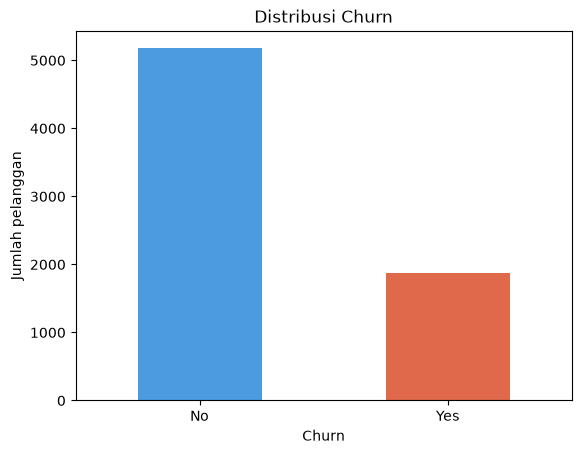

In [6]:
# perbandingan jumlah churn vs tidak
print(df["Churn"].value_counts())
print("\npersentase churn: {:.1f}%".format((df["Churn"] == "Yes").mean() * 100))

df["Churn"].value_counts().plot(kind="bar", color=["#4C9BE0", "#E0694C"])
plt.title("Distribusi Churn")
plt.xlabel("Churn")
plt.ylabel("Jumlah pelanggan")
plt.xticks(rotation=0)
plt.show()


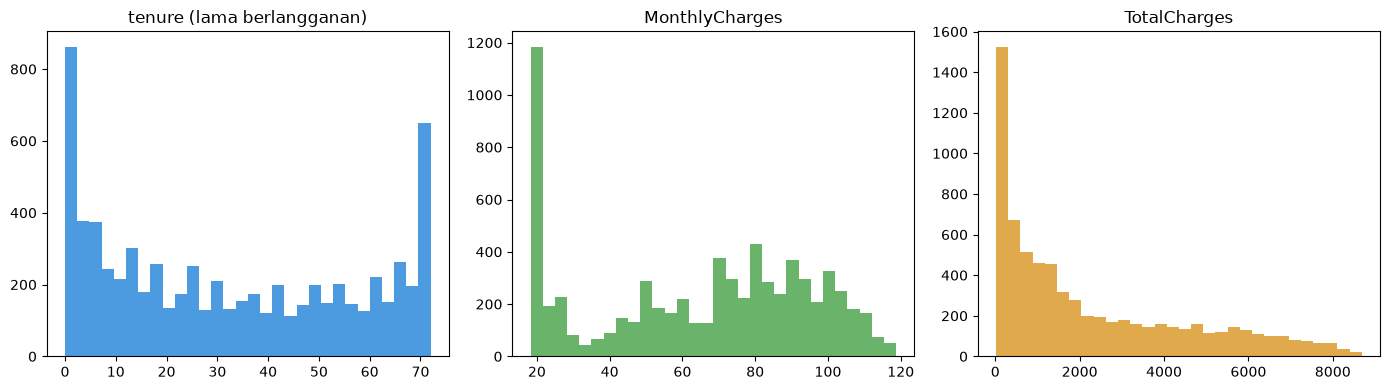

In [7]:
# lihat sebaran kolom angka yang utama
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

ax[0].hist(df["tenure"], bins=30, color="#4C9BE0")
ax[0].set_title("tenure (lama berlangganan)")

ax[1].hist(df["MonthlyCharges"], bins=30, color="#69B36A")
ax[1].set_title("MonthlyCharges")

ax[2].hist(pd.to_numeric(df["TotalCharges"], errors="coerce").dropna(), bins=30, color="#E0A94C")
ax[2].set_title("TotalCharges")

plt.tight_layout()
plt.show()


Contract
Month-to-month   42.70
One year         11.30
Two year          2.80
Name: Churn, dtype: float64


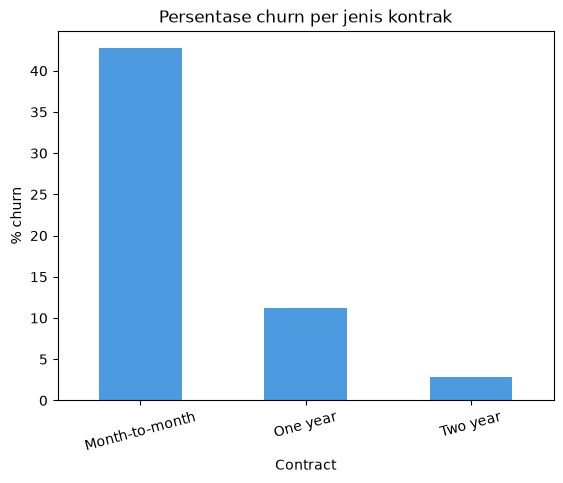

In [8]:
# churn dilihat dari jenis kontrak
tabel_kontrak = df.groupby("Contract")["Churn"].apply(lambda x: (x == "Yes").mean() * 100)
print(tabel_kontrak.round(1))

tabel_kontrak.plot(kind="bar", color="#4C9BE0")
plt.title("Persentase churn per jenis kontrak")
plt.ylabel("% churn")
plt.xticks(rotation=15)
plt.show()


In [9]:
# churn dilihat dari rata-rata tenure dan tagihan
print(df.groupby("Churn")[["tenure", "MonthlyCharges"]].mean().round(2))


       tenure  MonthlyCharges
Churn                        
No      37.57           61.27
Yes     17.98           74.44


Beberapa hal menarik dari EDA:

1. Sekitar 26,5% pelanggan berakhir churn (1869 dari 7043), jadi datanya sedikit tidak seimbang tetapi masih aman untuk klasifikasi biasa.
2. Pelanggan dengan kontrak month-to-month jauh lebih sering churn dibanding yang kontraknya satu atau dua tahun.
3. Pelanggan yang churn rata-rata tenure-nya lebih pendek (sekitar 18 bulan berbanding 38 bulan) dan MonthlyCharges-nya justru lebih tinggi.
4. Kolom customerID isinya hanya nomor identitas dan tidak membantu prediksi, jadi nanti dibuang di tahap preprocessing.


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [10]:
# kerja di salinan biar data mentah tetap utuh
df_prep = df.copy()

# 1. TotalCharges diubah jadi angka, yang kosong diisi median
df_prep["TotalCharges"] = pd.to_numeric(df_prep["TotalCharges"], errors="coerce")
df_prep["TotalCharges"] = df_prep["TotalCharges"].fillna(df_prep["TotalCharges"].median())

# 2. customerID dibuang karena cuma identitas
df_prep = df_prep.drop("customerID", axis=1)

df_prep.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
# 3. ubah kolom Yes/No menjadi 1/0
kolom_yesno = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
for kolom in kolom_yesno:
    df_prep[kolom] = df_prep[kolom].map({"Yes": 1, "No": 0})

# 4. sisanya yang masih berupa teks di-one-hot encoding
kolom_teks = df_prep.select_dtypes(include="object").columns.tolist()
print("kolom yang di-one-hot:", kolom_teks)

df_prep = pd.get_dummies(df_prep, columns=kolom_teks, drop_first=True)

# hasil one-hot kadang jadi True/False, diubah ke 0/1 biar seragam sama kolom lain
kolom_bool = df_prep.select_dtypes(include="bool").columns.tolist()
if len(kolom_bool) > 0:
    df_prep[kolom_bool] = df_prep[kolom_bool].astype(int)

print("\nbentuk data sekarang:", df_prep.shape)
df_prep.head()


kolom yang di-one-hot: ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

bentuk data sekarang: (7043, 31)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,34,1,0,56.95,1889.50,0,1,...,0,0,0,0,0,1,0,0,0,1
2,0,0,0,2,1,1,53.85,108.15,1,1,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,45,0,0,42.30,1840.75,0,1,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,2,1,1,70.70,151.65,1,0,...,0,0,0,0,0,0,0,0,1,0


In [12]:
# 5. scaling kolom angka ke rentang 0-1
kolom_angka = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = MinMaxScaler()
df_prep[kolom_angka] = scaler.fit_transform(df_prep[kolom_angka])

df_prep[kolom_angka].describe()


,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,0.45,0.46,0.26
std,0.34,0.30,0.26
min,0.00,0.00,0.00
25%,0.12,0.17,0.04
50%,0.40,0.52,0.16
75%,0.76,0.71,0.43
max,1.00,1.00,1.00


In [13]:
# 6. simpan hasil preprocessing + nama kolom untuk dipakai tahap selanjutnya
df_prep.to_csv("telco_churn_preprocessing.csv", index=False)

# nama kolom disimpan supaya file lain (inference/monitoring) tahu urutan fiturnya
kolom_fitur = [c for c in df_prep.columns if c != "Churn"]
with open("kolom_fitur.json", "w") as f:
    json.dump(kolom_fitur, f)

print("file tersimpan: telco_churn_preprocessing.csv")
print("jumlah baris:", df_prep.shape[0], "| jumlah kolom:", df_prep.shape[1])
print("kolom target: Churn | jumlah fitur:", len(kolom_fitur))


file tersimpan: telco_churn_preprocessing.csv
jumlah baris: 7043 | jumlah kolom: 31
kolom target: Churn | jumlah fitur: 30


Ringkasan preprocessing yang dilakukan:

1. `TotalCharges` diubah ke numerik, 11 nilai kosong diisi median.
2. `customerID` dihapus.
3. Kolom Yes/No diubah ke 1/0, kolom teks lain di-one-hot encoding.
4. Kolom numerik di-scale dengan MinMaxScaler.

Data sekarang sudah siap dipakai untuk training model di tahap berikutnya. File `automate_Anggara-Budiyanto.py` di folder ini isinya langkah yang sama dalam bentuk fungsi supaya bisa dijalankan otomatis.
